In [1]:
# we will plot the error graphs
import numpy as np
import matplotlib.pyplot as plt
from utils import DATA_DIR
import itertools
from tucker_tensor import TuckerDecomposition

2026-01-09 09:39:18.224735: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Semantic Error analysis


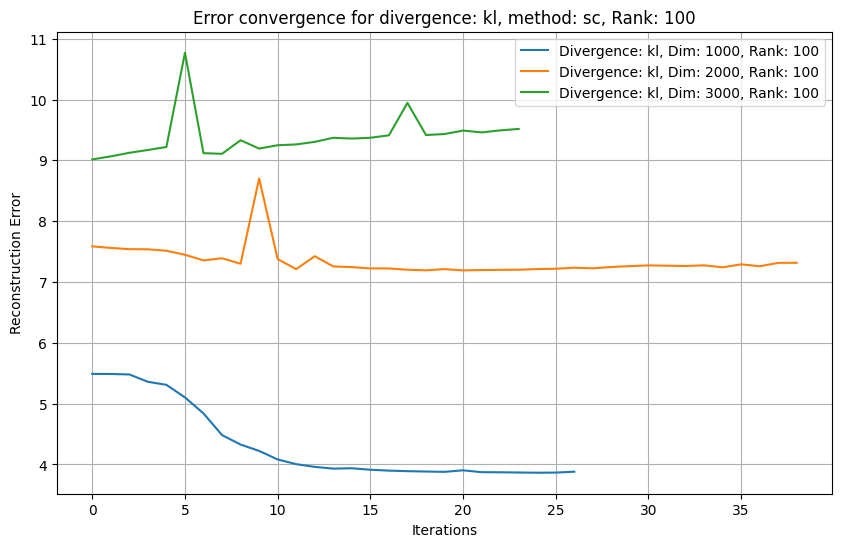

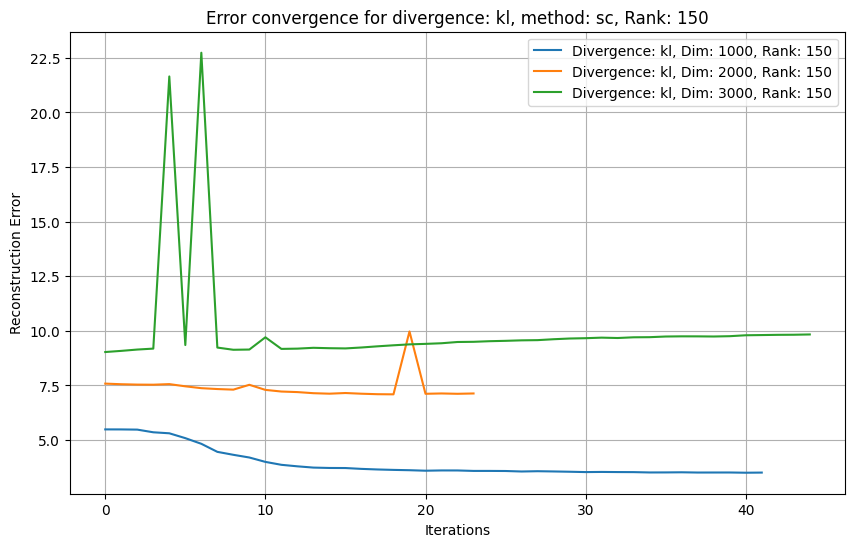

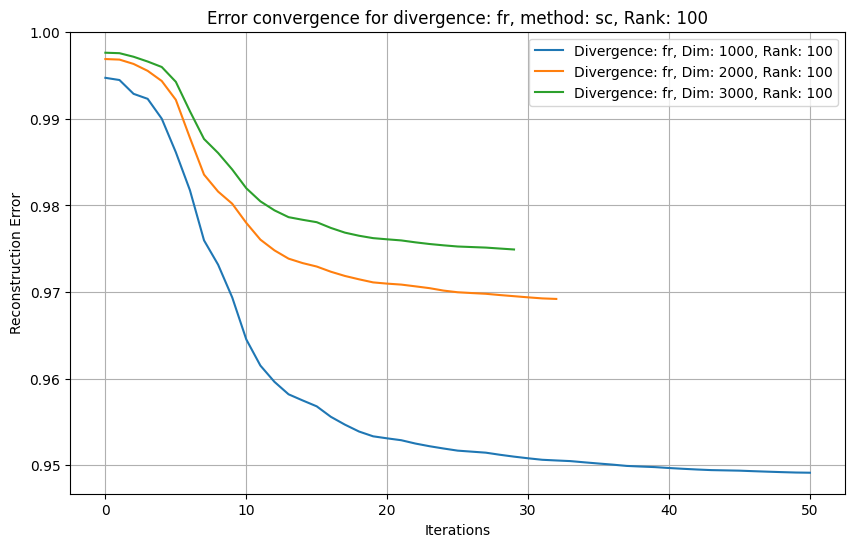

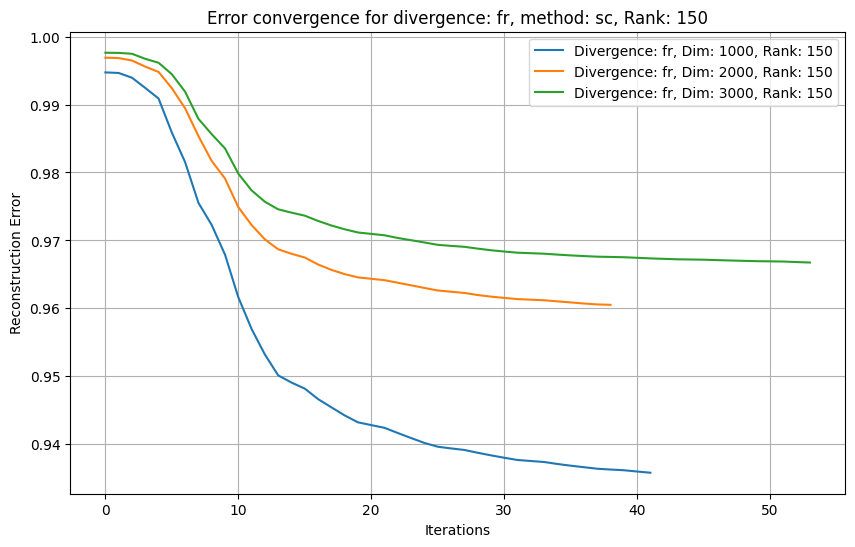

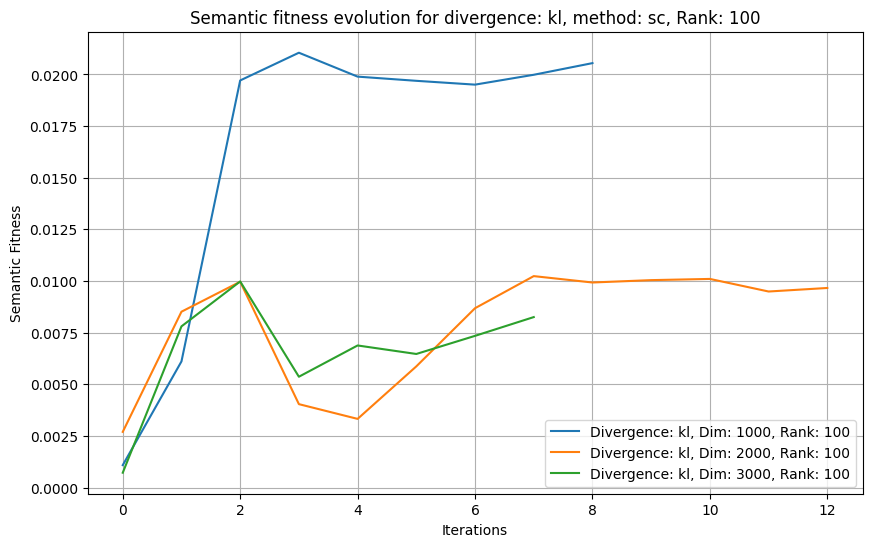

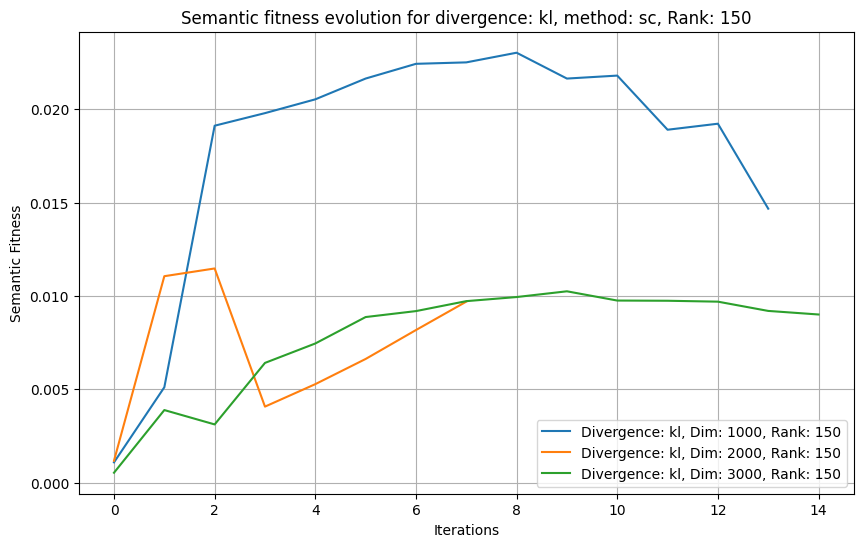

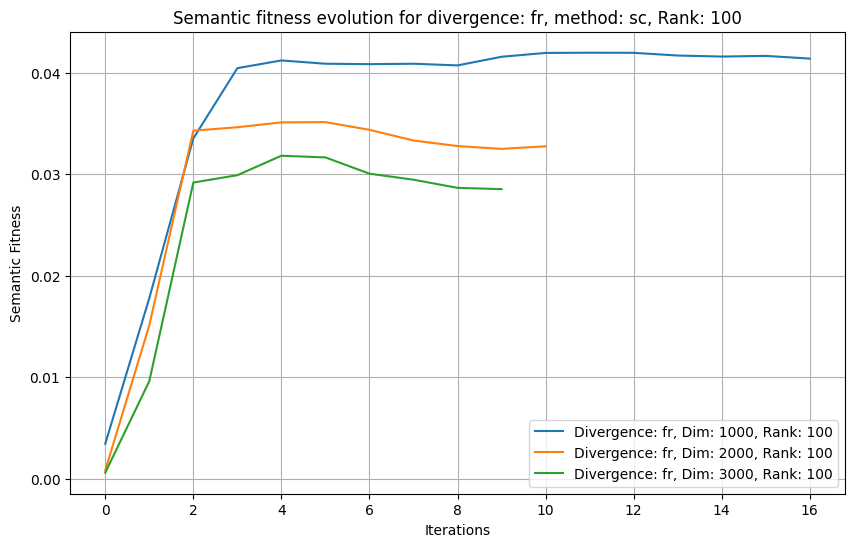

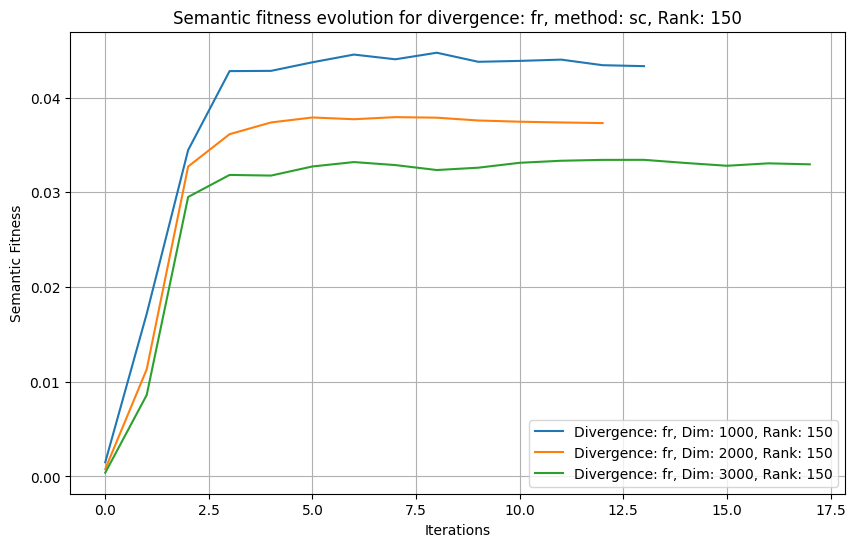

In [2]:
errors_dir = DATA_DIR / "tensors/lassy/decomposition"
errors = {}
sem_errors = {}
tensors = {}
methods = ["sc"]
divergences = ["kl", "fr"]
dims = [1000, 2000, 3000]
ranks = [100, 150]
iters = 750
name = None
for divergence, method, dim, rank in itertools.product(divergences, methods, dims, ranks):
    key = (divergence, method, dim, rank)
    try:
        errors[key] = np.load(errors_dir / f"{divergence}_{method}_{dim}d_{rank}r_{iters}i_errors.npy")
        sem_errors[key] = np.load(errors_dir / f"{divergence}_{method}_{dim}d_{rank}r_{iters}i_fitness.npy")
        tensors[key] = TuckerDecomposition.load_from_disk(
            dataset="lassy",
            method=method,
            divergence=divergence,
            dims=dim,
            rank=rank,
            iterations=iters,

        )
    except FileNotFoundError:
        print(f"File not found for {divergence} dim {dim} rank {rank}")
# we plot the errors for each method, dim and rank

for divergence in divergences:
    for method in methods:
        for rank in ranks:
            plt.figure(figsize=(10, 6))
            for dim in dims:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(errors[key], label=f"Divergence: {divergence}, Dim: {dim}, Rank: {rank}")
            plt.title(f"Error convergence for divergence: {divergence}, method: {method}, Rank: {rank}")
            plt.xlabel("Iterations")
            plt.ylabel("Reconstruction Error")
            plt.legend()
            plt.grid(True)
            plt.show()

for divergence in divergences:
    for method in methods:
        for rank in ranks:
            plt.figure(figsize=(10, 6))
            for dim in dims:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(sem_errors[key], label=f"Divergence: {divergence}, Dim: {dim}, Rank: {rank}")
            plt.title(f"Semantic fitness evolution for divergence: {divergence}, method: {method}, Rank: {rank}")
            plt.xlabel("Iterations")
            plt.ylabel("Semantic Fitness")
            plt.legend()
            plt.grid(True)
            plt.show()


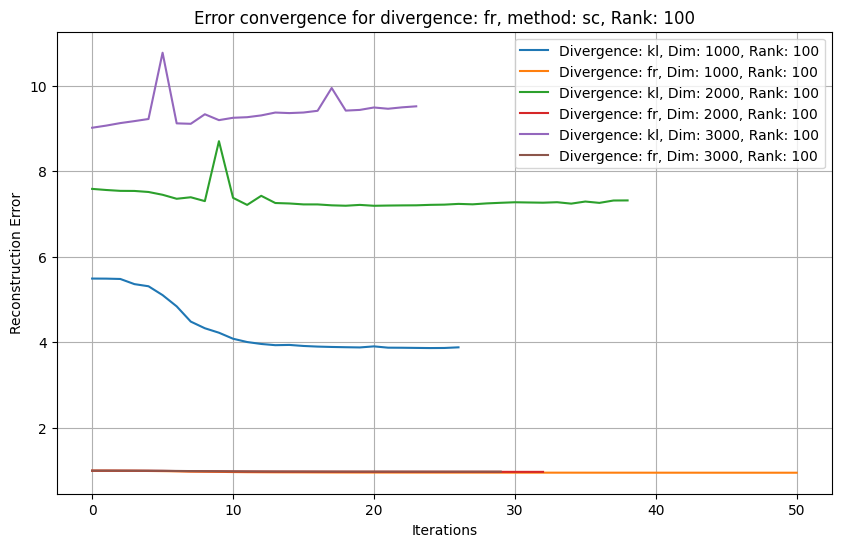

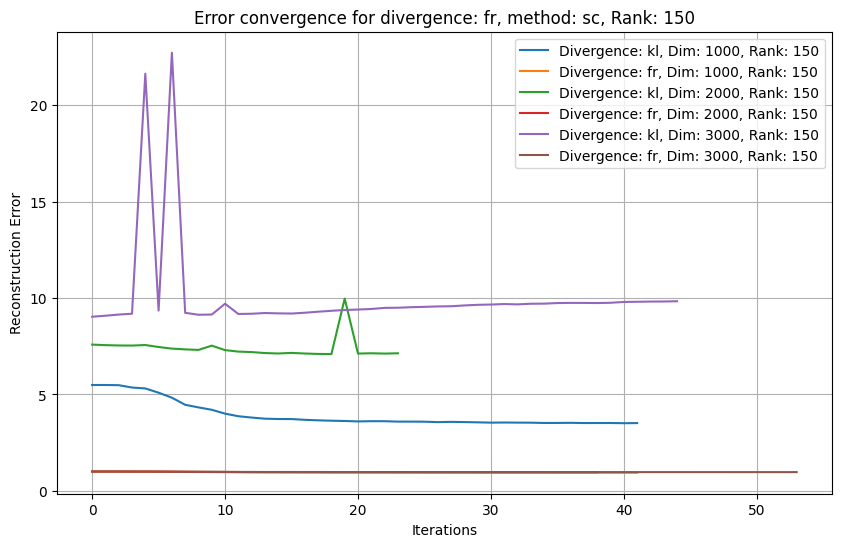

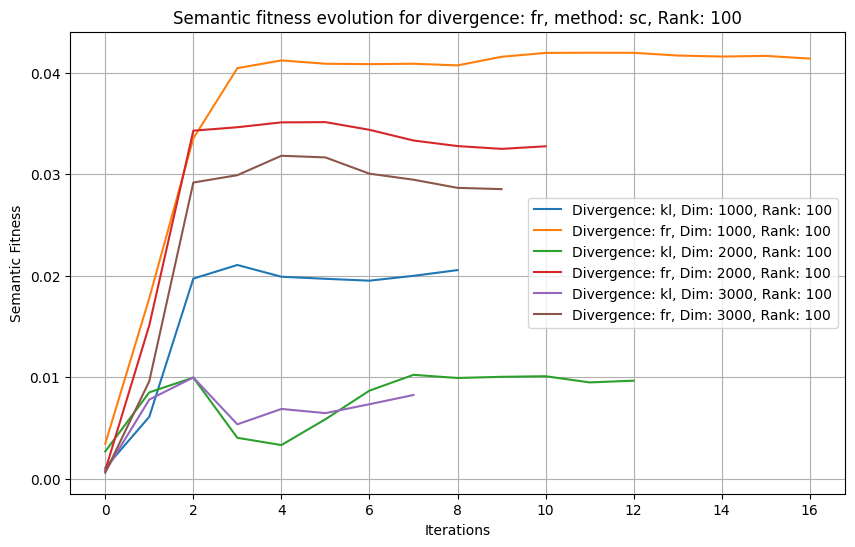

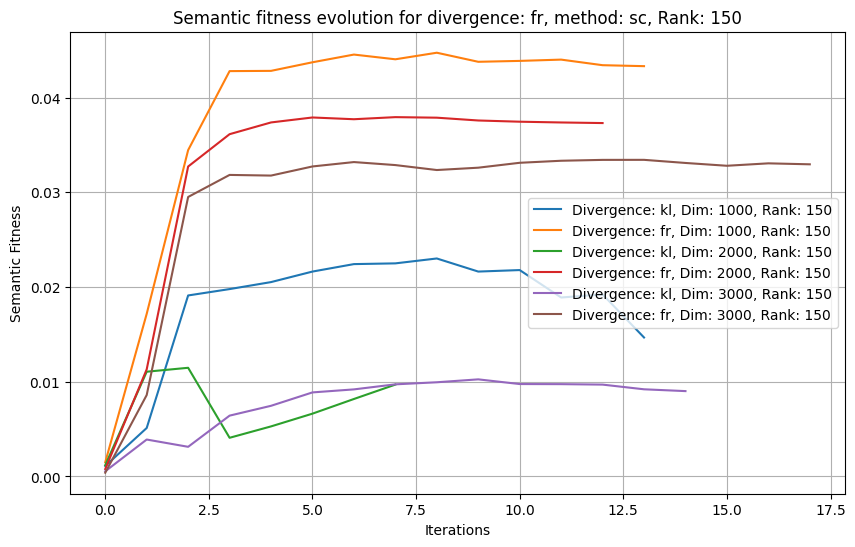

In [3]:
for method in methods:
    for rank in ranks:
        plt.figure(figsize=(10, 6))
        for dim in dims:
            for divergence in divergences:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(errors[key], label=f"Divergence: {divergence}, Dim: {dim}, Rank: {rank}")
        plt.title(f"Error convergence for divergence: {divergence}, method: {method}, Rank: {rank}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.legend()
        plt.grid(True)
        plt.show()

for method in methods:
    for rank in ranks:
        plt.figure(figsize=(10, 6))
        for dim in dims:
            for divergence in divergences:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(sem_errors[key], label=f"Divergence: {divergence}, Dim: {dim}, Rank: {rank}")
        plt.title(f"Semantic fitness evolution for divergence: {divergence}, method: {method}, Rank: {rank}")
        plt.xlabel("Iterations")
        plt.ylabel("Semantic Fitness")
        plt.legend()
        plt.grid(True)
        plt.show()


In [4]:
for key, tensor in tensors.items():
    print(key, "\n\t", tensor.get_top_words_for_dimension("verb", 1, 5))
    tensor.factors

('kl', 'sc', 1000, 100) 
	 [('eisen', 3.830875357380137e-06), ('toe_zeggen', 1.5989447774700238e-06), ('beloven', 1.4853477523502079e-06), ('stellen', 1.0007448736359947e-06), ('vragen', 6.770592335669789e-07)]
('kl', 'sc', 1000, 150) 
	 [('delen', 2.0421903172973543e-06), ('uiten', 1.749322223076888e-06), ('uit_spreken', 1.5881321360211587e-06), ('koesteren', 1.2299800573600805e-06), ('voelen', 8.504916877427604e-07)]
('kl', 'sc', 2000, 100) 
	 [('lezen', 1.5759037408358267e-09), ('kennen', 1.4705179296470305e-09), ('downloaden', 1.4169110329476098e-09), ('beluisteren', 1.3216082672684593e-09), ('bekijken', 1.160018747725644e-09)]
('kl', 'sc', 2000, 150) 
	 [('op_doen', 4.141524623246795e-11), ('terug_willen', 1.454418096374921e-11), ('verwachten', 1.3056978241665629e-11), ('klagen', 1.2919811054334929e-11), ('zoeken', 1.1869469816738754e-11)]
('kl', 'sc', 3000, 100) 
	 [('krijgen', 2.651946884313361e-09), ('betalen', 1.3540329968364517e-09), ('verdienen', 8.957989905411523e-10), ('on

In [5]:
tensor = tensors[key]

In [6]:
id = tensor.vocab["s2i"]["kat"]
s_factor = tensor.factors[1][id]

In [7]:
tensor.get_top_words_for_dimension("subject", s_factor, 5)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

	Loaded kl sc dim 1000 rank 150
	Loaded kl scSoftPlus dim 1000 rank 150
	Loaded kl scShifted dim 1000 rank 150
	Loaded kl siiSoftPlus dim 1000 rank 150
	Loaded kl siiShifted dim 1000 rank 150
File not found for kl counting dim 1000 rank 150 500
	Loaded fr sc dim 1000 rank 150
	Loaded fr scSoftPlus dim 1000 rank 150
	Loaded fr scShifted dim 1000 rank 150
	Loaded fr siiSoftPlus dim 1000 rank 150
	Loaded fr siiShifted dim 1000 rank 150
File not found for fr counting dim 1000 rank 150 500


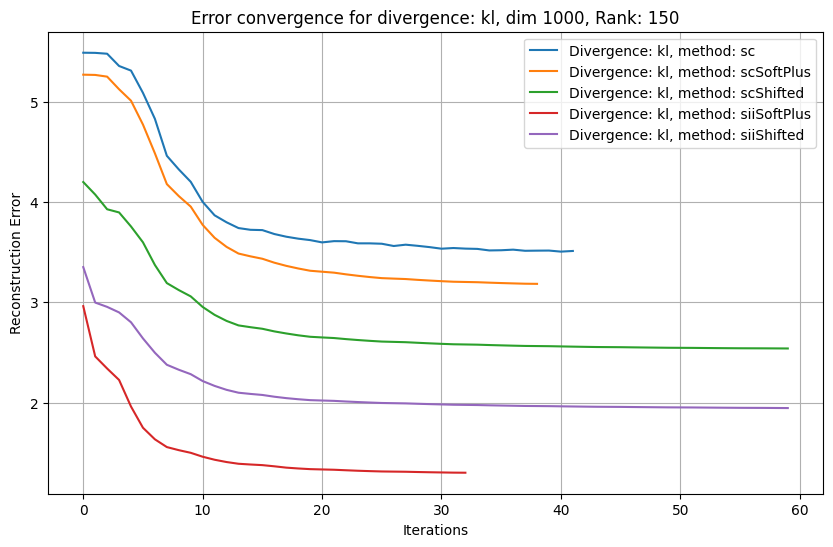

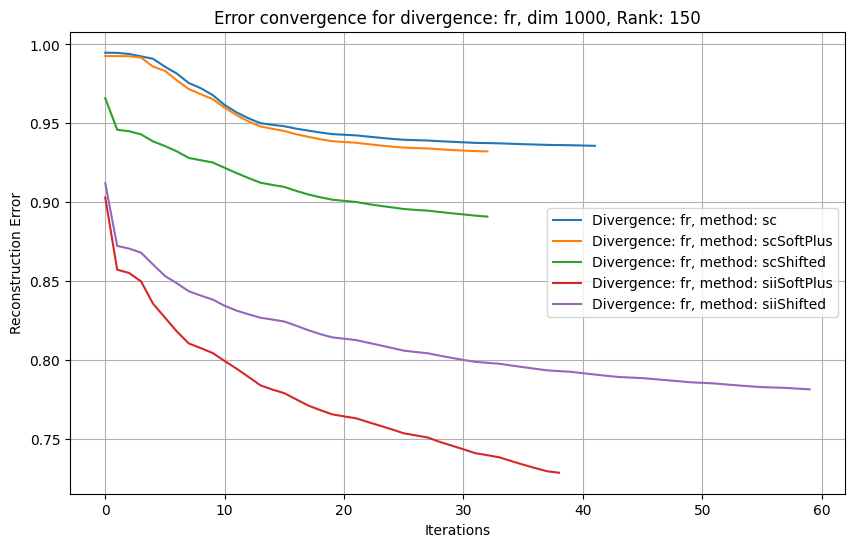

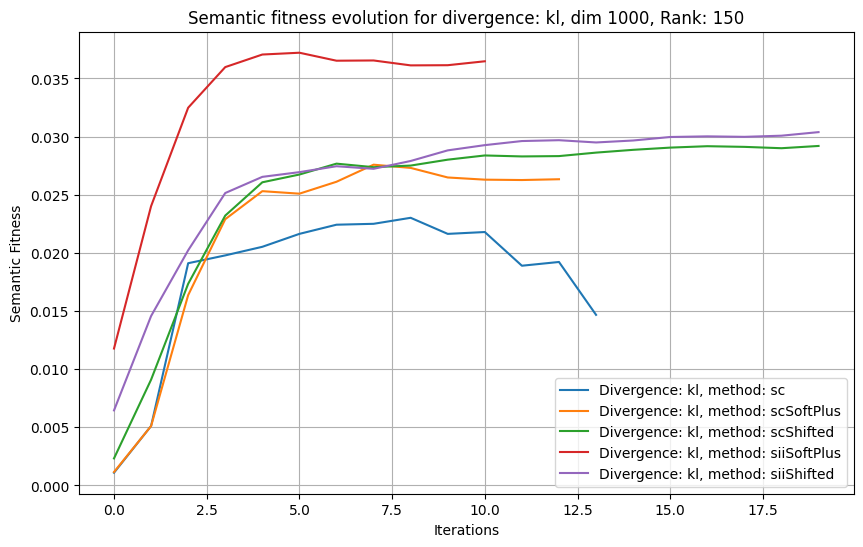

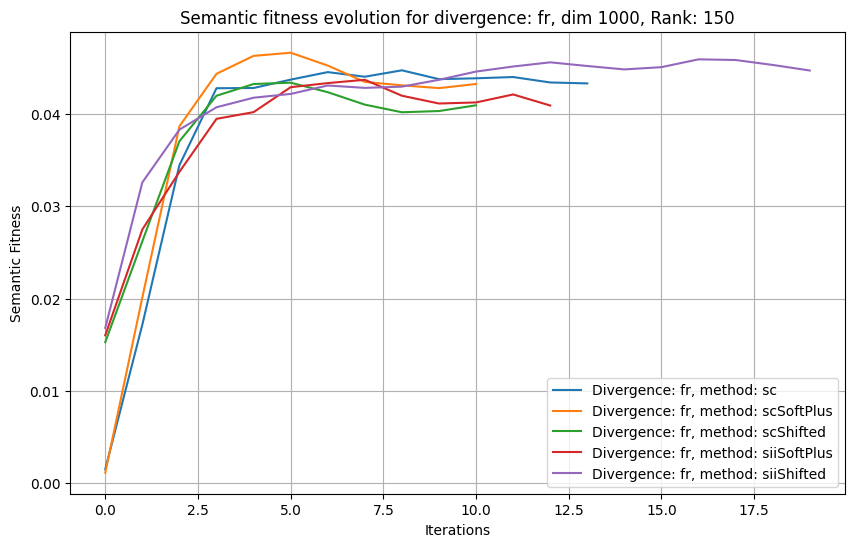

In [2]:
errors_dir = DATA_DIR / "tensors/lassy/decomposition"
errors = {}
sem_errors = {}
tensors = {}
methods = ["sc", "scSoftPlus", "scShifted", "siiSoftPlus", "siiShifted", "counting"]
divergences = ["kl", "fr"]
dims = [1000]
ranks = [150]
name = None
for divergence, method, dim, rank in itertools.product(divergences, methods, dims, ranks):
    key = (divergence, method, dim, rank)
    iters = 750 if method == 'sc' else 500
    try:
        errors[key] = np.load(errors_dir / f"{divergence}_{method}_{dim}d_{rank}r_{iters}i_errors.npy")
        sem_errors[key] = np.load(errors_dir / f"{divergence}_{method}_{dim}d_{rank}r_{iters}i_fitness.npy")
        tensors[key] = TuckerDecomposition.load_from_disk(
            dataset="lassy",
            method=method,
            divergence=divergence,
            dims=dim,
            rank=rank,
            iterations=iters

        )
        print(f"\tLoaded {divergence} {method} dim {dim} rank {rank}")
    except FileNotFoundError:
        print(f"File not found for {divergence} {method} dim {dim} rank {rank} {iters}")
# we plot the errors for each method, dim and rank

for divergence in divergences:
    for dim in dims:
        for rank in ranks:
            plt.figure(figsize=(10, 6))
            for method in methods:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(errors[key], label=f"Divergence: {divergence}, method: {method}")
            plt.title(f"Error convergence for divergence: {divergence}, dim {dim}, Rank: {rank}")
            plt.xlabel("Iterations")
            plt.ylabel("Reconstruction Error")
            plt.legend()
            plt.grid(True)
            plt.show()

for divergence in divergences:
    for dim in dims:
        for rank in ranks:
            plt.figure(figsize=(10, 6))
            for method in methods:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(sem_errors[key], label=f"Divergence: {divergence}, method: {method}")
            plt.title(f"Semantic fitness evolution for divergence: {divergence}, dim {dim}, Rank: {rank}")
            plt.xlabel("Iterations")
            plt.ylabel("Semantic Fitness")
            plt.legend()
            plt.grid(True)
            plt.show()


	Loaded kl sc dim 2000 rank 150
File not found for kl scSoftPlus dim 2000 rank 150 500
File not found for kl scShifted dim 2000 rank 150 500
	Loaded kl siiSoftPlus dim 2000 rank 150
File not found for kl siiShifted dim 2000 rank 150 500
File not found for kl counting dim 2000 rank 150 500
	Loaded fr sc dim 2000 rank 150
File not found for fr scSoftPlus dim 2000 rank 150 500
File not found for fr scShifted dim 2000 rank 150 500
	Loaded fr siiSoftPlus dim 2000 rank 150
	Loaded fr siiShifted dim 2000 rank 150
File not found for fr counting dim 2000 rank 150 500


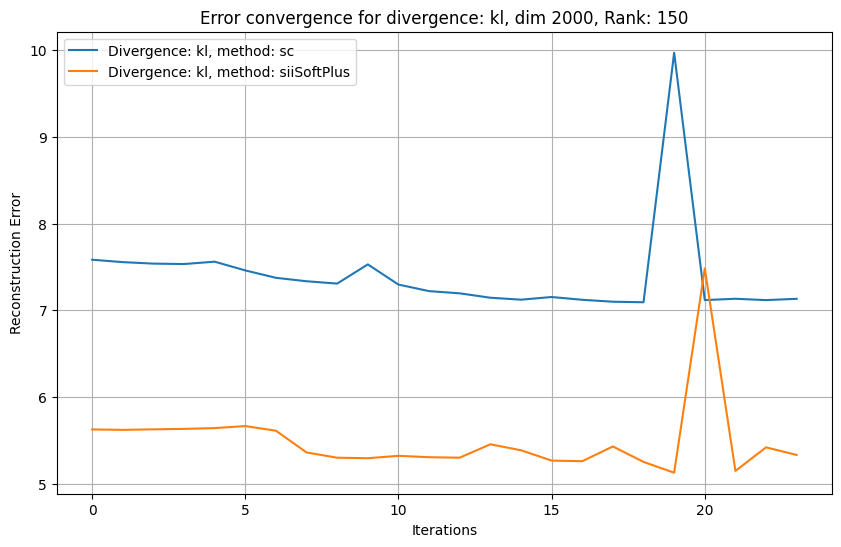

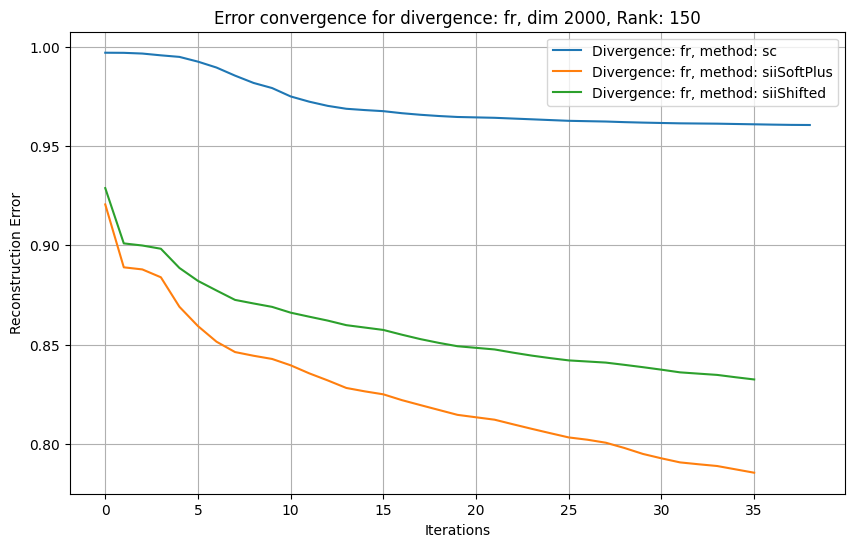

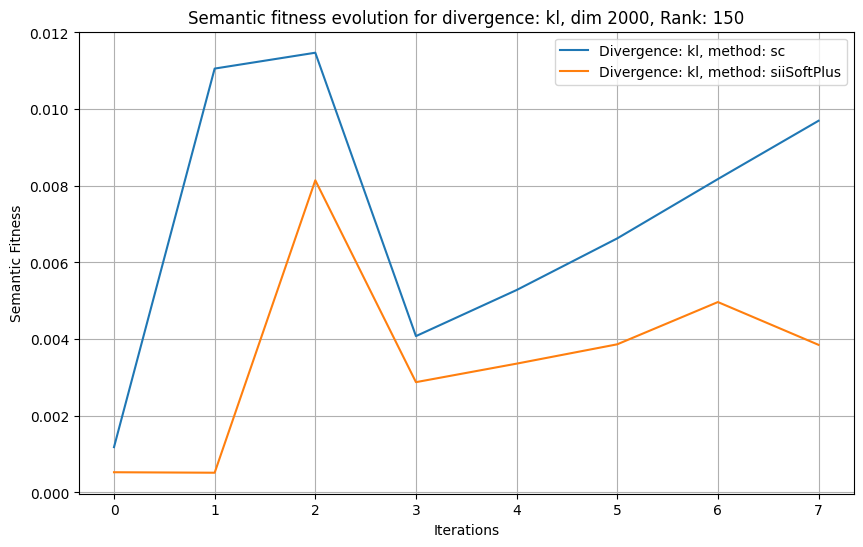

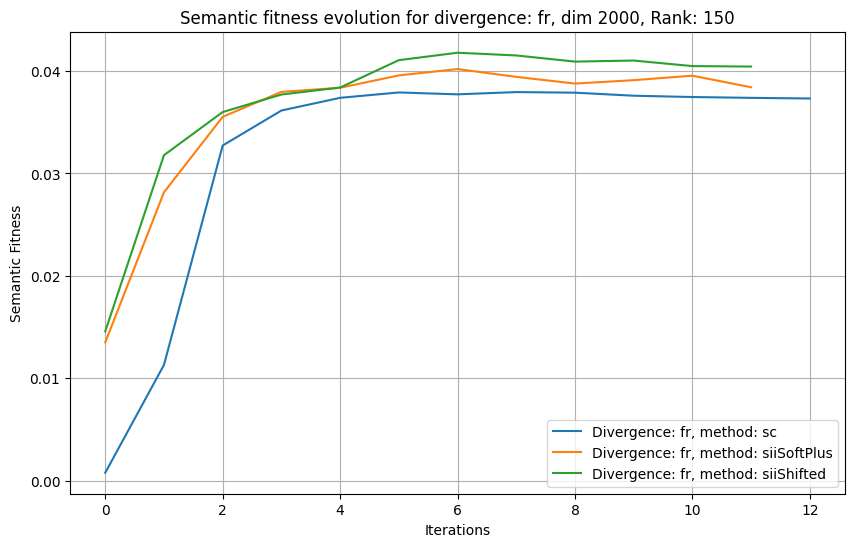

In [5]:
errors = {}
sem_errors = {}
tensors = {}

dims = [2000]

for divergence, method, dim, rank in itertools.product(divergences, methods, dims, ranks):
    key = (divergence, method, dim, rank)
    iters = 750 if method == 'sc' else 500
    try:
        errors[key] = np.load(errors_dir / f"{divergence}_{method}_{dim}d_{rank}r_{iters}i_errors.npy")
        sem_errors[key] = np.load(errors_dir / f"{divergence}_{method}_{dim}d_{rank}r_{iters}i_fitness.npy")
        tensors[key] = TuckerDecomposition.load_from_disk(
            dataset="lassy",
            method=method,
            divergence=divergence,
            dims=dim,
            rank=rank,
            iterations=iters

        )
        print(f"\tLoaded {divergence} {method} dim {dim} rank {rank}")
    except FileNotFoundError:
        print(f"File not found for {divergence} {method} dim {dim} rank {rank} {iters}")
# we plot the errors for each method, dim and rank

for divergence in divergences:
    for dim in dims:
        for rank in ranks:
            plt.figure(figsize=(10, 6))
            for method in methods:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(errors[key], label=f"Divergence: {divergence}, method: {method}")
            plt.title(f"Error convergence for divergence: {divergence}, dim {dim}, Rank: {rank}")
            plt.xlabel("Iterations")
            plt.ylabel("Reconstruction Error")
            plt.legend()
            plt.grid(True)
            plt.show()

for divergence in divergences:
    for dim in dims:
        for rank in ranks:
            plt.figure(figsize=(10, 6))
            for method in methods:
                key = (divergence, method, dim, rank)
                if key in sem_errors:
                    plt.plot(sem_errors[key], label=f"Divergence: {divergence}, method: {method}")
            plt.title(f"Semantic fitness evolution for divergence: {divergence}, dim {dim}, Rank: {rank}")
            plt.xlabel("Iterations")
            plt.ylabel("Semantic Fitness")
            plt.legend()
            plt.grid(True)
            plt.show()


# OOV or Not OOV
Not _technically_ comparable! less OOV -> more `None` elements -> Benefits high-probability elements


In [10]:
errors_dir = DATA_DIR / "tensors/preOOV-fineweb-en/decomposition"
errors = {}
sem_errors = {}
tensors = {}
methods = ["sc", "scSoftPlus", "scShifted", "siiSoftPlus", "siiShifted", "counting"]
divergences = ["kl", "fr"]
dims = [1000, 2000]
ranks = [150]
iters = 500
names = [None, "NoOOV"]

for name, divergence, method, dim, rank in itertools.product(names, divergences, methods, dims, ranks):
    key = (name, divergence, method, dim, rank)
    iters = 750 if method == 'sc' else 500
    try:
        errors[key] = np.load(errors_dir /
                              f"{name+'_' if name else ''}{divergence}_{method}_{dim}d_{rank}r_{iters}i_errors.npy")
        sem_errors[key] = np.load(errors_dir /
                                  f"{name+'_' if name else ''}{divergence}_{method}_{dim}d_{rank}r_{iters}i_fitness.npy")
        tensors[key] = TuckerDecomposition.load_from_disk(
            dataset="preOOV-fineweb-en",
            name=name,
            method=method,
            divergence=divergence,
            dims=dim,
            rank=rank,
            iterations=iters

        )
        print(f"\tLoaded {name} {divergence} {method} dim {dim} rank {rank}")
    except FileNotFoundError:
        print(f"File not found for {name} {divergence} {method} dim {dim} rank {rank} {iters}")

File not found for None kl sc dim 1000 rank 150 750
File not found for None kl sc dim 2000 rank 150 750
	Loaded None kl scSoftPlus dim 1000 rank 150
	Loaded None kl scSoftPlus dim 2000 rank 150
	Loaded None kl scShifted dim 1000 rank 150
File not found for None kl scShifted dim 2000 rank 150 500
	Loaded None kl siiSoftPlus dim 1000 rank 150
	Loaded None kl siiSoftPlus dim 2000 rank 150
	Loaded None kl siiShifted dim 1000 rank 150
	Loaded None kl siiShifted dim 2000 rank 150
	Loaded None kl counting dim 1000 rank 150
	Loaded None kl counting dim 2000 rank 150
File not found for None fr sc dim 1000 rank 150 750
File not found for None fr sc dim 2000 rank 150 750
	Loaded None fr scSoftPlus dim 1000 rank 150
	Loaded None fr scSoftPlus dim 2000 rank 150
	Loaded None fr scShifted dim 1000 rank 150
	Loaded None fr scShifted dim 2000 rank 150
	Loaded None fr siiSoftPlus dim 1000 rank 150
	Loaded None fr siiSoftPlus dim 2000 rank 150
	Loaded None fr siiShifted dim 1000 rank 150
	Loaded None fr 

In [14]:
# we delete those files that do not have a counterpart
to_delete = []
for divergence, method, dim, rank in itertools.product(divergences, methods, dims, ranks):
    if not ((names[0], divergence, method, dim, rank) in errors.keys()
            and (names[1], divergence, method, dim, rank) in errors.keys()):
        to_delete.append([divergence, method, dim, rank])
to_delete

[['kl', 'sc', 1000, 150],
 ['kl', 'sc', 2000, 150],
 ['kl', 'scSoftPlus', 1000, 150],
 ['kl', 'scSoftPlus', 2000, 150],
 ['kl', 'scShifted', 2000, 150],
 ['kl', 'siiShifted', 2000, 150],
 ['fr', 'sc', 1000, 150],
 ['fr', 'sc', 2000, 150],
 ['fr', 'scSoftPlus', 1000, 150],
 ['fr', 'scSoftPlus', 2000, 150]]

In [15]:
len(errors)

33

In [18]:
for name in names:
    for el in to_delete:
        try:
            key = (name, el[0], el[1], el[2], el[3])
            del errors[key]
            del sem_errors[key]
            del tensors[key]
        except KeyError:
            continue
len(errors)

28

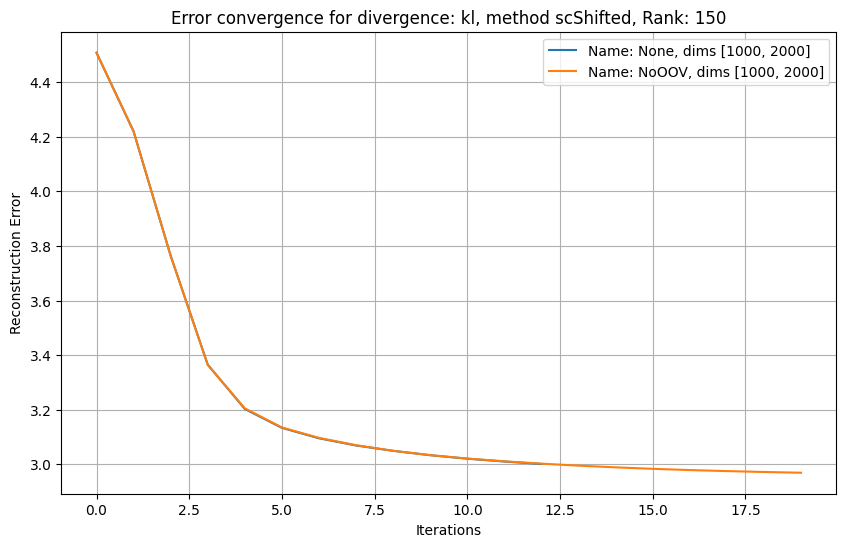

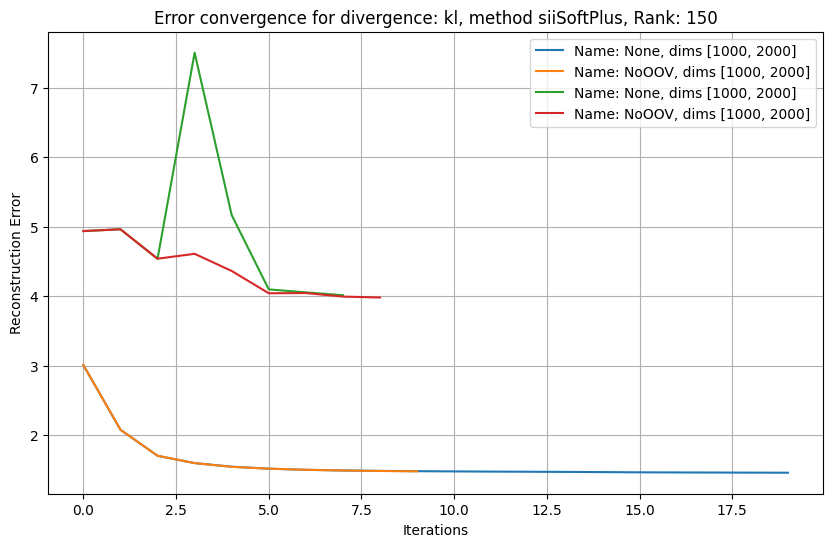

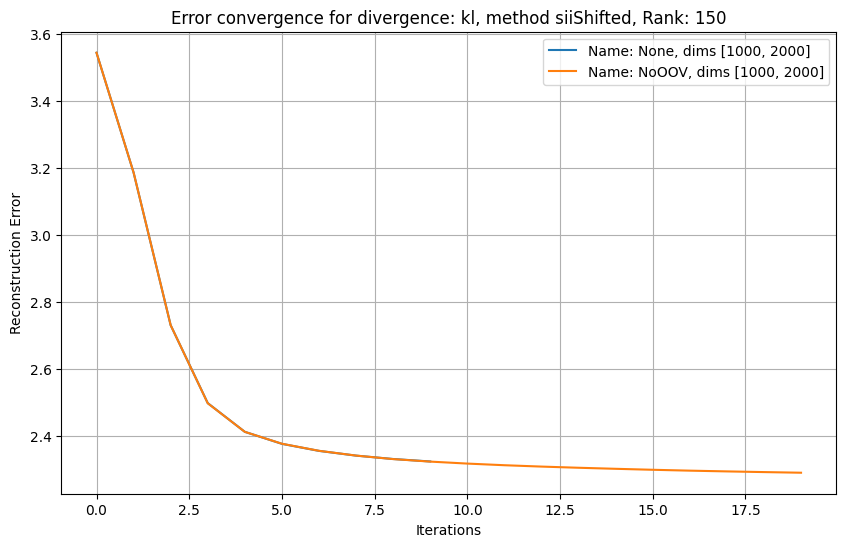

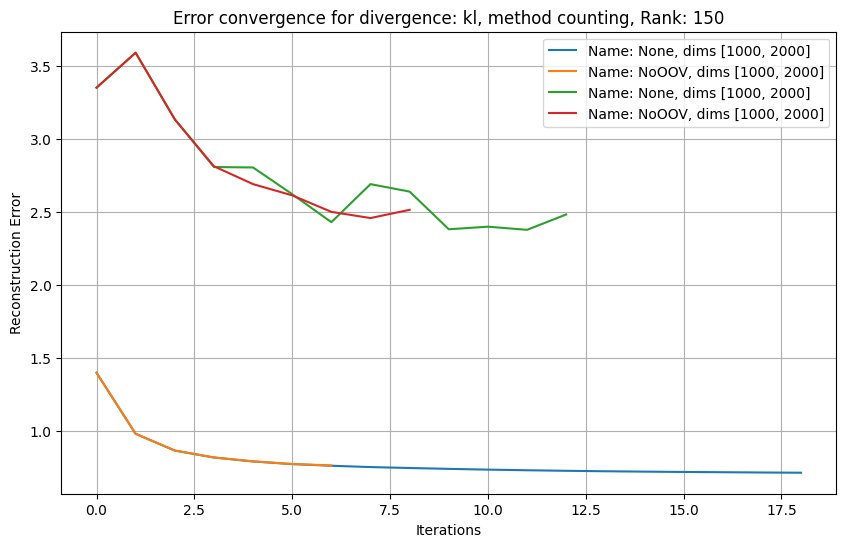

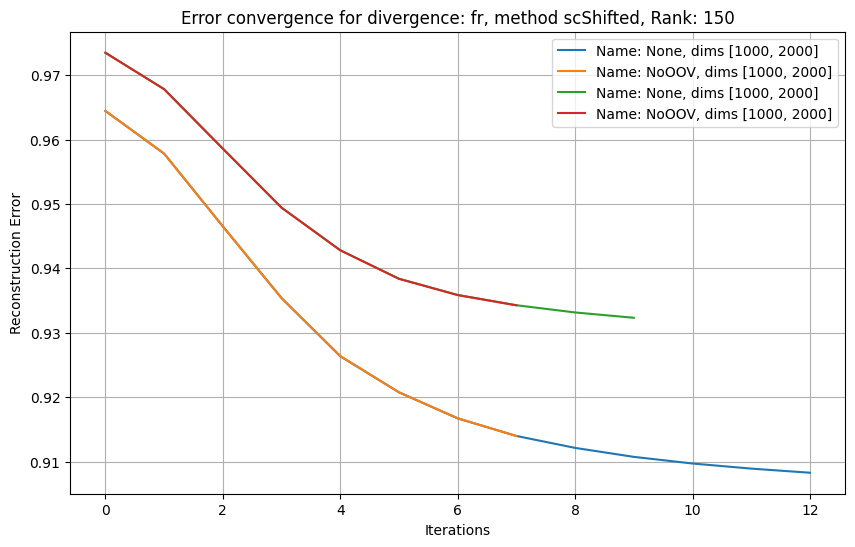

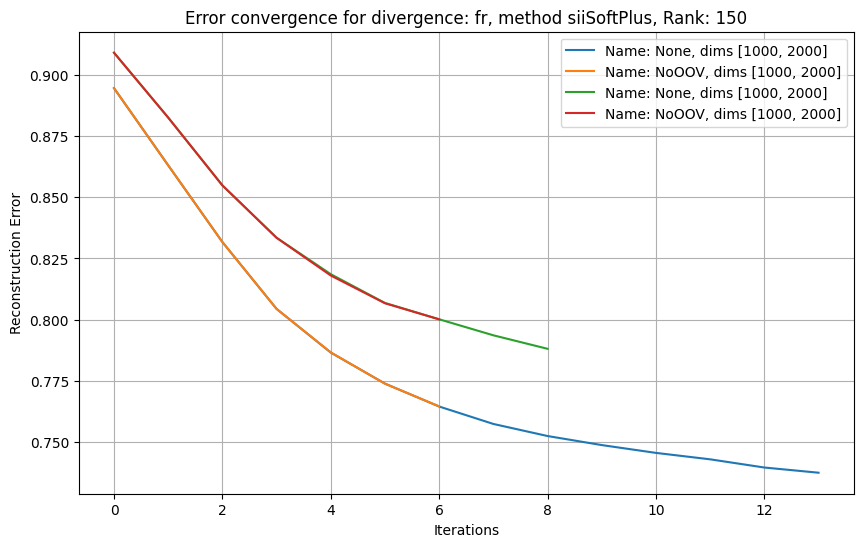

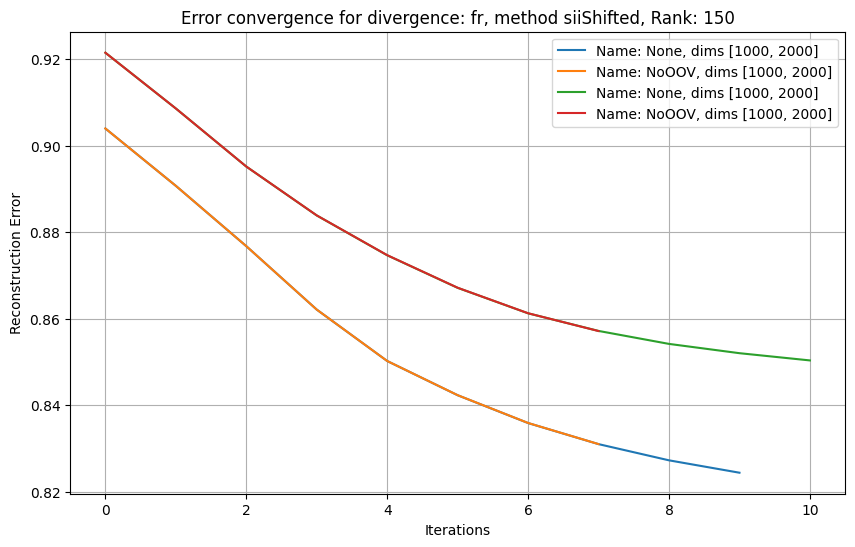

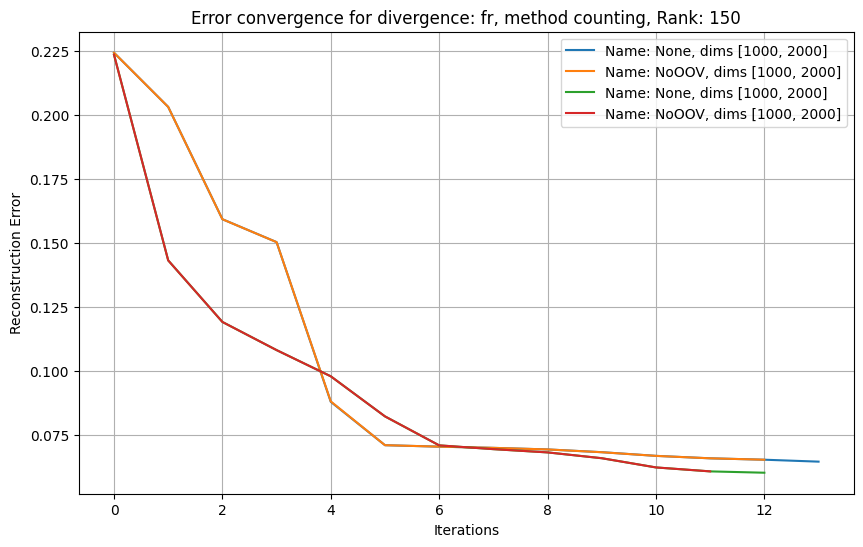

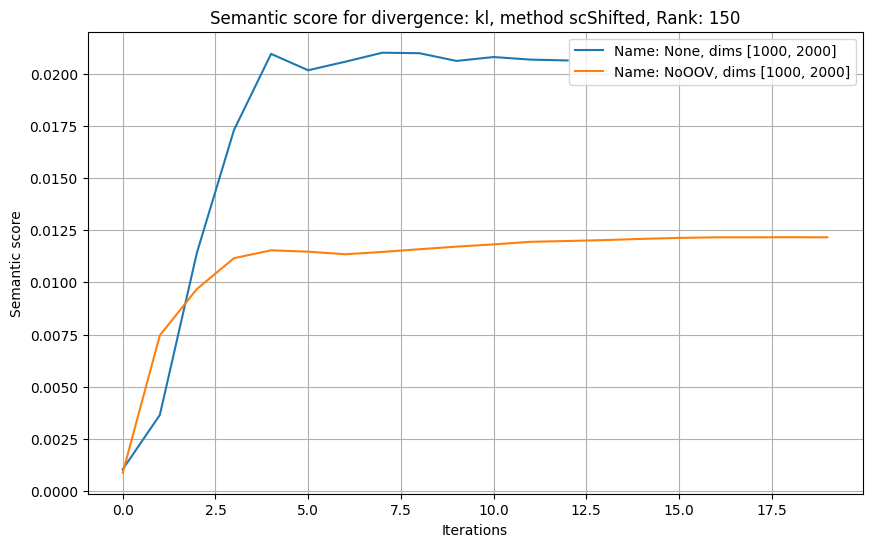

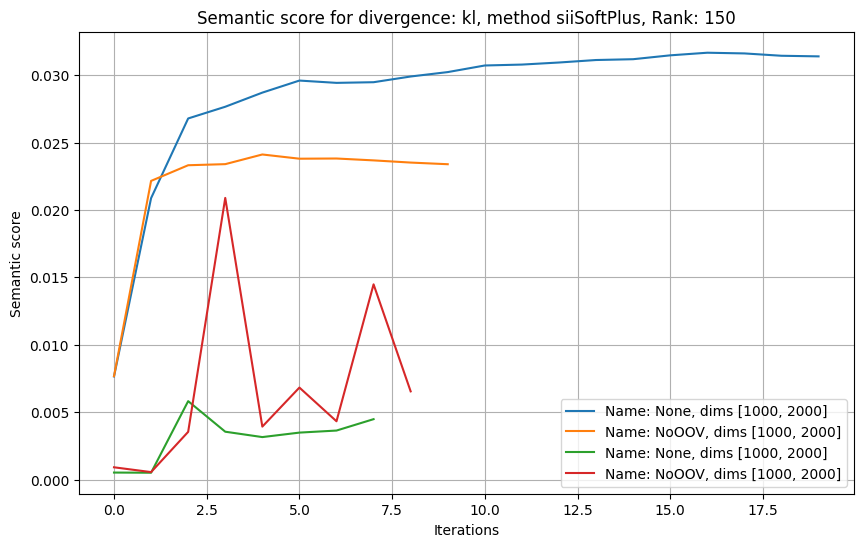

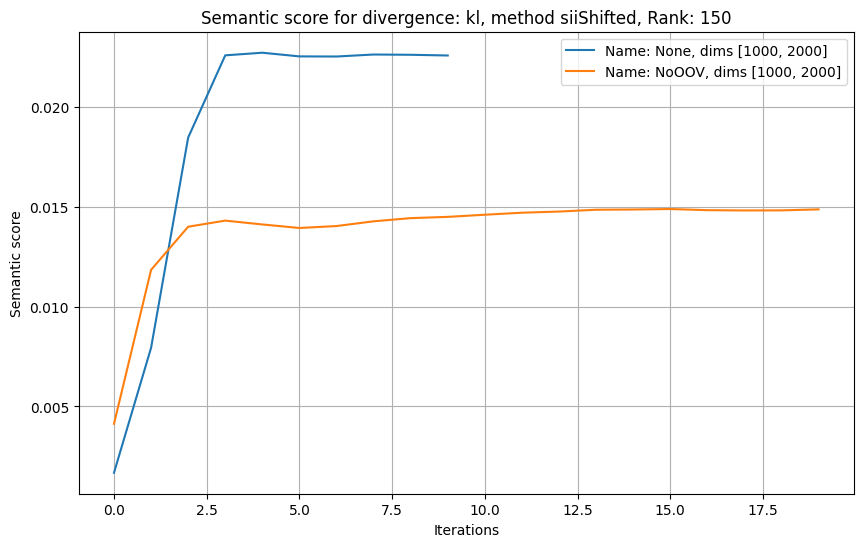

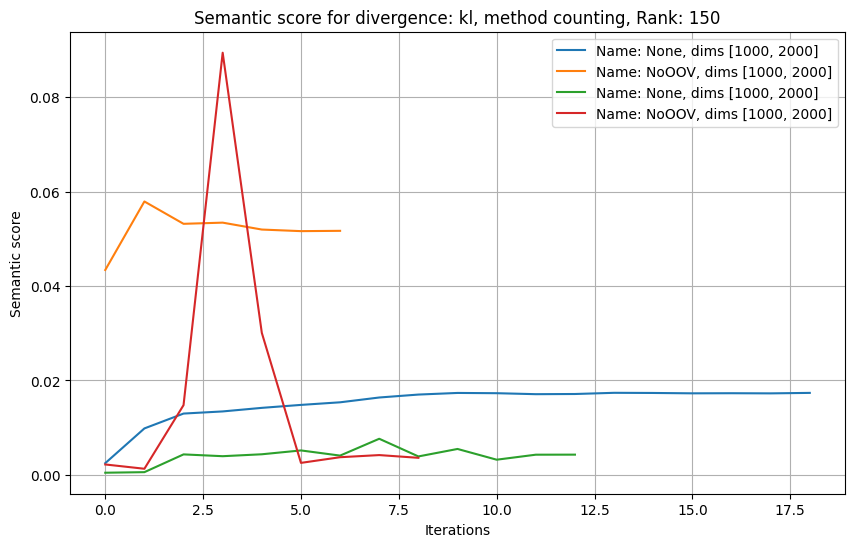

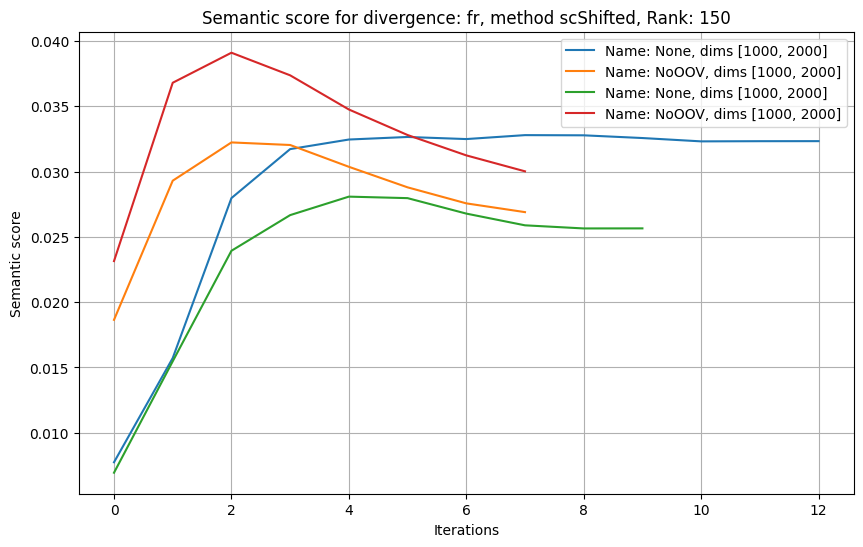

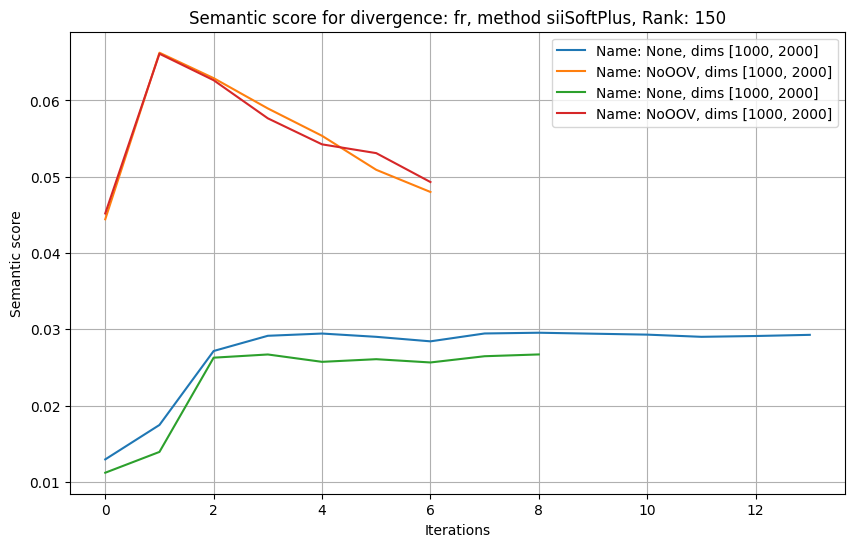

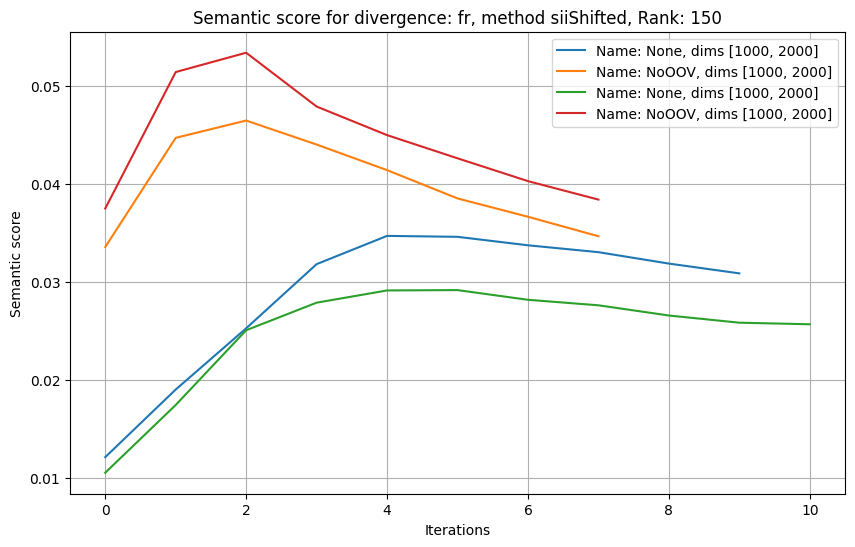

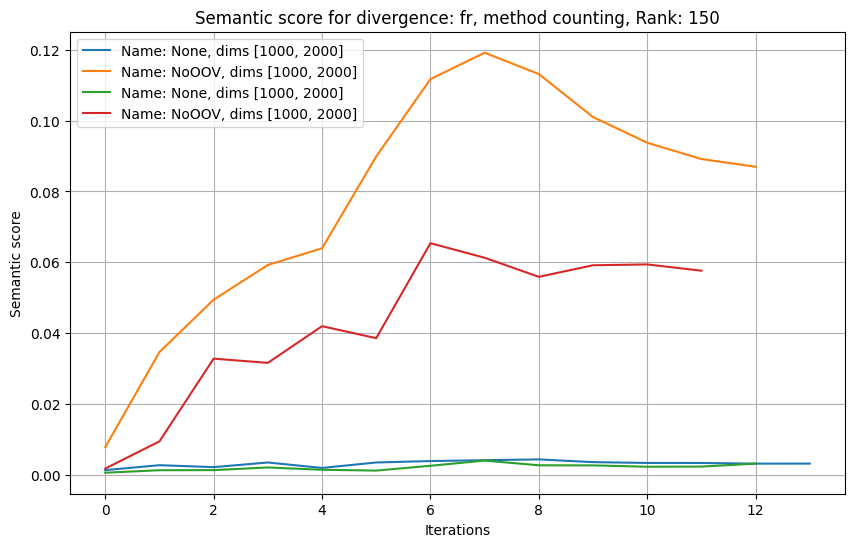

In [25]:
# we plot the errors for each method, dim and rank
# plot errors
for divergence in divergences:
    for rank in ranks:
        for method in methods:
            plt.figure(figsize=(10, 6))
            plotted = False
            for dim in dims:
                for name in names:
                    key = (name, divergence, method, dim, rank)
                    if key in errors:
                        plt.plot(
                            errors[key],
                            label=f"Name: {name}, dims {dims}"
                        )
                        plotted = True

            if plotted:
                plt.title(f"Error convergence for divergence: {divergence}, method {method}, Rank: {rank}")
                plt.xlabel("Iterations")
                plt.ylabel("Reconstruction Error")
                plt.legend()
                plt.grid(True)
                plt.show()
            else:
                plt.close()
# plot sem errors
for divergence in divergences:
    for rank in ranks:
        for method in methods:
            plt.figure(figsize=(10, 6))
            plotted = False
            for dim in dims:
                for name in names:
                    key = (name, divergence, method, dim, rank)
                    if key in sem_errors:
                        plt.plot(
                            sem_errors[key],
                            label=f"Name: {name}, dims {dims}"
                        )
                        plotted = True

            if plotted:
                plt.title(f"Semantic score for divergence: {divergence}, method {method}, Rank: {rank}")
                plt.xlabel("Iterations")
                plt.ylabel("Semantic score")
                plt.legend()
                plt.grid(True)
                plt.show()
            else:
                plt.close()
